# 기계식키보드 제품명 학습

In [1]:
import requests, time, json
import pandas as pd

# ── 발급받은 키 입력 (네이버 개발자센터 → 애플리케이션 → 검색 API) ──
CLIENT_ID     = "Y7n03Br_kFGnH39UTACm"
CLIENT_SECRET = "PNpqoa1XvU"

API_URL = "https://openapi.naver.com/v1/search/shop.json"

def fetch_shopping(query, total=100, sort="sim", exclude="used:rental:cbshop"):
    """query를 total개까지 수집. sort: sim(유사도)/date/asc/dsc"""
    headers = {"X-Naver-Client-Id": CLIENT_ID,
               "X-Naver-Client-Secret": CLIENT_SECRET}
    items, total = [], min(total, 1000)          # 네이버 전체 상한 1000
    for start in range(1, total + 1, 100):
        params = {"query": query,
                  "display": min(100, total - start + 1),   # 요청당 상한 100
                  "start": start, "sort": sort, "exclude": exclude}
        r = requests.get(API_URL, headers=headers, params=params)
        if r.status_code != 200:
            print(f"[{r.status_code}] {r.text}"); break
        batch = r.json().get("items", [])
        if not batch: break
        items.extend(batch)
        time.sleep(0.1)
    return items

# ── 호출 ──
query = "기계식키보드"
items = fetch_shopping(query, total=300)
print(f"수집: {len(items)}건\n")

# ── 1) 원시 JSON 1건 그대로 보기 (더러움 확인) ──
print("─── raw JSON 샘플 ───")
print(json.dumps(items[0], ensure_ascii=False, indent=2))

# ── 2) 표로 보기 (정제 X, 온 그대로) ──
df = pd.DataFrame(items)
cols = ["title","brand","maker","mallName","lprice","hprice",
        "productType","category1","category2","category3","category4"]
df = df[[c for c in cols if c in df.columns]]
display(df.head(10))

# df.to_csv(f"naver_{query}.csv", index=False, encoding="utf-8-sig")  # 필요시 저장

수집: 300건

─── raw JSON 샘플 ───
{
  "title": "저소음 사무실 사무용 게이밍 풀배열 컴퓨터 자판기 <b>기계식</b> 키감 조약돌 무소음 보글보글 <b>키보드</b>",
  "link": "https://smartstore.naver.com/main/products/12130861208",
  "image": "https://shopping-phinf.pstatic.net/main_8967537/89675371913.2.jpg",
  "lprice": "21900",
  "hprice": "",
  "mallName": "맥스틸 공식스토어",
  "productId": "89675371913",
  "productType": "2",
  "brand": "맥스틸",
  "maker": "맥스틸",
  "category1": "디지털/가전",
  "category2": "주변기기",
  "category3": "키보드",
  "category4": "유선키보드"
}


,title,brand,maker,mallName,lprice,hprice,productType,category1,category2,category3,category4
0,저소음 사무실 사무용 게이밍 풀배열 컴퓨터 자판기 <b>기계식</b> 키감 조약돌 ...,맥스틸,맥스틸,맥스틸 공식스토어,21900,,2,디지털/가전,주변기기,키보드,유선키보드
1,커세어 K70 PRO TKL MGX 래피드트리거 게이밍 <b>기계식 키보드</b> ...,커세어,커세어,네이버,220000,,1,디지털/가전,주변기기,키보드,유선키보드
2,프리플로우 archon AK68 DualDial 유무선 <b>기계식 키보드</b> ...,프리플로우,프리플로우,네이버,77900,,1,디지털/가전,주변기기,키보드,무선키보드
3,"AULA F108 스카이블랙, 저소음 바다축",AULA,AULA,네이버,79000,,1,디지털/가전,주변기기,키보드,무선키보드
4,"AULA F87 Pro 유무선 <b>기계식 키보드</b> 인디고 블랙, 회목축 V4",AULA,AULA,네이버,62000,,1,디지털/가전,주변기기,키보드,무선키보드
5,지클릭커 파도프로젝트 WK107 제주스위치 8K 풀윤활 무선 블루투스 <b>기계식 ...,지클릭커,지클릭커,네이버,79800,,1,디지털/가전,주변기기,키보드,무선키보드
6,지클릭커 MagneonX 8K RGB 래피드트리거 XRT68 자석축 마그네틱 게이밍...,지클릭커,지클릭커,네이버,69800,,1,디지털/가전,주변기기,키보드,유선키보드
7,VARO V108 파스텔 저소음 게이밍 <b>기계식 키보드</b> 풀배열 유 무선 ...,,,VARO 공식스토어,79000,,2,디지털/가전,주변기기,키보드,무선키보드
8,지클릭커 슈퍼히어로 GK-580X 풀배열 게이밍 <b>기계식 키보드</b> 108키...,지클릭커,지클릭커,네이버,27400,,1,디지털/가전,주변기기,키보드,유선키보드
9,VARO VM87 HE 8K 마그네틱 자석축 저소음 사무용 게이밍 <b>기계식</b...,,,VARO 공식스토어,145000,,2,디지털/가전,주변기기,키보드,유선키보드


In [4]:
len(df[df['title']==df['제품명']])

0

In [3]:
import pandas as pd

df = pd.read_csv(f"naver_{query}_제품명.csv")

datasets = []

for title, product in zip(df["title"], df["제품명"]):
    datasets.append([
        {"role": "system", "content": "다음 텍스트를 보고 상품명을 추출하세요. 단, 상품명만 출력할 것.",},
        {"role": "user", "content": title,},
        {"role": "assistant", "content": product}
    ])

datasets[:5]

[[{'role': 'system', 'content': '다음 텍스트를 보고 상품명을 추출하세요. 단, 상품명만 출력할 것.'},
  {'role': 'user',
   'content': '저소음 사무실 사무용 게이밍 풀배열 컴퓨터 자판기 기계식 키감 조약돌 무소음 보글보글 키보드'},
  {'role': 'assistant', 'content': '맥스틸'}],
 [{'role': 'system', 'content': '다음 텍스트를 보고 상품명을 추출하세요. 단, 상품명만 출력할 것.'},
  {'role': 'user',
   'content': '프리플로우 archon AK68 DualDial 유무선 기계식 키보드 말차라떼, 저소음 디딤돌축'},
  {'role': 'assistant', 'content': '프리플로우 archon AK68 DualDial'}],
 [{'role': 'system', 'content': '다음 텍스트를 보고 상품명을 추출하세요. 단, 상품명만 출력할 것.'},
  {'role': 'user',
   'content': '커세어 K70 PRO TKL MGX 래피드트리거 게이밍 기계식 키보드 화이트, 마그네틱축'},
  {'role': 'assistant', 'content': '커세어 K70 PRO TKL'}],
 [{'role': 'system', 'content': '다음 텍스트를 보고 상품명을 추출하세요. 단, 상품명만 출력할 것.'},
  {'role': 'user',
   'content': 'VARO V108 파스텔 저소음 게이밍 기계식 키보드 풀배열 유 무선 블루투스 사무용'},
  {'role': 'assistant', 'content': 'VARO V108'}],
 [{'role': 'system', 'content': '다음 텍스트를 보고 상품명을 추출하세요. 단, 상품명만 출력할 것.'},
  {'role': 'user', 'content': 'AULA F108 스카이블랙, 저소음 바다축'},
  

# 상품명 추출 Fine-tuning (Qwen2.5-1.5B-Instruct)

네이버 쇼핑 `title` → 정제된 `제품명`을 추출하도록 QLoRA로 학습합니다.
앞에서 만든 `datasets`(총 300개)를 **train 250 / test 50**으로 랜덤 분할합니다.

> ⚠️ Colab 기준 런타임 → **T4 GPU** 선택 후 실행하세요.

## 1. 패키지 설치

In [6]:
!pip install -q --upgrade transformers datasets accelerate peft trl bitsandbytes evaluate rouge-score nltk

import warnings
warnings.filterwarnings("ignore")
import transformers
transformers.logging.set_verbosity_error()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.8/838.8 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.8 MB/s eta 0:00:00


## 2. 모델 로드
bitsandbytes로 4bit 양자화된 Qwen2.5-1.5B-Instruct를 불러옵니다.

In [5]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

# 4비트 양자화 설정 코드 (설정값은 거의 고정)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# 모델 로드
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

# 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print("✅ 모델 로드 완료")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


✅ 모델 로드 완료


## 3. LoRA 설정
학습할 레이어만 선택해 메모리를 아낍니다.

In [6]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(model, lora_config)
model.gradient_checkpointing_enable()
model.print_trainable_parameters()
print("✅ LoRA 설정 완료")

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
✅ LoRA 설정 완료


## 4. 데이터 분할 (train 250 / test 50)
앞 셀의 `datasets`를 랜덤 셔플 후 250/50으로 나누고, Qwen 채팅 템플릿을 적용합니다.

In [7]:
import random
from datasets import Dataset

random.seed(42)

# 위 셀에서 만든 datasets(총 300개)를 250/50으로 랜덤 분할
data = datasets[:]            # List[List[message dict]]
random.shuffle(data)
train_msgs = data[:250]
test_msgs  = data[250:300]
print(f"train: {len(train_msgs)}개 / test: {len(test_msgs)}개")

def to_text(msgs):
    return tokenizer.apply_chat_template(
        msgs, tokenize=False, add_generation_prompt=False,
    )

train_dataset = Dataset.from_list([{"text": to_text(m)} for m in train_msgs])
eval_dataset  = Dataset.from_list([{"text": to_text(m)} for m in test_msgs])

print("\n--- 학습 샘플 확인 ---")
print(train_dataset[0]["text"])

train: 250개 / test: 50개

--- 학습 샘플 확인 ---
<|im_start|>system
다음 텍스트를 보고 상품명을 추출하세요. 단, 상품명만 출력할 것.<|im_end|>
<|im_start|>user
한성컴퓨터 TFG Magnetox 2XF 듀얼 8K 래피드트리거 자석축 게이밍 키보드 그레이레이니, POLARIS2<|im_end|>
<|im_start|>assistant
한성컴퓨터 TFG Magnetox 2XF<|im_end|>



## 4-1. 학습 전 베이스 모델 테스트

학습 전에 먼저 모델 성능을 확인해 봅시다.

In [8]:
def generate_product(msgs, max_new_tokens=64):
    """system+user만 넣어 제품명을 생성 (정답 제외)"""
    model.eval()
    prompt = msgs[:-1]
    inputs = tokenizer.apply_chat_template(
        prompt, tokenize=True, add_generation_prompt=True,
        return_tensors="pt", return_dict=False
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(
            input_ids=inputs, max_new_tokens=max_new_tokens, do_sample=False,
        )
    return tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True).strip()

# ── 학습 전 베이스 모델로 테스트셋 10건 미리 확인 ──
print("=== 학습 전(베이스 모델) 예측 ===\n")
for msgs in test_msgs[:10]:
    title = str(msgs[1]["content"])
    gold  = str(msgs[-1]["content"]).strip()
    pred  = generate_product(msgs)
    print(f"입력: {title}")
    print(f"정답: {gold}")
    print(f"예측: {pred}")
    print("-" * 60)

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


=== 학습 전(베이스 모델) 예측 ===



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


입력: 커세어 뱅가드 PRO 96 핫스왑 8K MGX 래피드트리거 게이밍 기계식키보드 블랙, MGX 하이퍼드라이브
정답: 커세어 뱅가드 PRO 96
예측: 커세어 뱅가드 PRO 96 핫스왑 8K MGX 래피드트리거 게이밍 기계식키보드
------------------------------------------------------------
입력: 앱코 AF108PRO ABKO x SOAI 콜라보 3모드 기계식 키보드 코랄 블루, 세이야축
정답: 앱코 AF108PRO
예측: 아파코 3모드 기계식 키보드
------------------------------------------------------------
입력: COX CK87 게이트론 LED 게이밍 기계식 크림블루, 갈축
정답: COX CK87
예측: 게이밍 기계식 크림블루 LED
------------------------------------------------------------
입력: 키네틱스 헤르츠87(Hertz87) CNC풀알루미늄 RGB VIA 유무선 키보드
정답: 키네틱스 헤르츠87(Hertz87)
예측: 키네틱스 헤르츠87(Hertz87) CNC풀알루미늄 RGB VIA 유무선 키보드
------------------------------------------------------------
입력: TFG Magnetox 2XL 듀얼8K 래피드트리거 자석축 게이밍 키보드 픽셀, POLARIS2, 35g
정답: 한성컴퓨터 TFG Magnetox 2XL
예측: 키보드
------------------------------------------------------------
입력: [신규출시] PMO WAVE75 유무선 CNC알루미늄 RGB VIA 기계식키보드 블랙, HMX 레서판다축
정답: PMO WAVE75
예측: PMO WAVE75
------------------------------------------------------------
입력: COX CK420 교체축 레인보우 LE

## 5. 학습 실행
약 5~10분 소요됩니다.

In [9]:
from trl import SFTTrainer, SFTConfig
from transformers import TrainerCallback
import torch
import evaluate

rouge_metric = evaluate.load("rouge")
bleu_metric  = evaluate.load("bleu")

# 매 epoch 끝에 test_msgs를 실제로 generate해서 ROUGE/BLEU를 측정하는 콜백
# (이 transformers 버전은 eval 시 logits를 넘겨주지 않아 compute_metrics로는 불가)
class GenMetricsCallback(TrainerCallback):
    def __init__(self, eval_msgs, tokenizer, max_new_tokens=64):
        self.eval_msgs = eval_msgs          # List[List[message dict]]
        self.tokenizer = tokenizer
        self.max_new_tokens = max_new_tokens
        self.history = []                   # epoch별 rouge/bleu 기록 (그래프용)

    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        model.eval()
        preds, refs = [], []
        for msgs in self.eval_msgs:
            prompt = msgs[:-1]   # system+user (정답 제외)
            gold   = str(msgs[-1]["content"])
            inputs = self.tokenizer.apply_chat_template(
                prompt, tokenize=True, add_generation_prompt=True,
                return_tensors="pt", return_dict=False,
            ).to(model.device)
            with torch.no_grad():
                out = model.generate(
                    input_ids=inputs,
                    max_new_tokens=self.max_new_tokens,
                    do_sample=False,
                )
            text = self.tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
            preds.append(text if text.strip() else " ")
            refs.append(gold)

        rouge = rouge_metric.compute(predictions=preds, references=refs)
        bleu  = bleu_metric.compute(predictions=preds, references=[[r] for r in refs])
        self.history.append({
            "epoch": round(state.epoch),
            "rougeL": rouge["rougeL"],
            "bleu": bleu["bleu"],
        })
        print(f"\n📊 [Epoch {state.epoch:.0f}] rougeL={rouge['rougeL']:.4f}  bleu={bleu['bleu']:.4f}")
        model.train()

gen_cb = GenMetricsCallback(test_msgs, tokenizer)   # 그래프에서 history 참조용

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    callbacks=[gen_cb],
    args=SFTConfig(
        max_length=512,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        num_train_epochs=3,
        learning_rate=2e-4,
        warmup_ratio=0.1,
        lr_scheduler_type="cosine",
        fp16=False,
        bf16=False,
        logging_steps=10,
        eval_strategy="epoch",
        output_dir="./product_output",
        report_to="none",
        gradient_checkpointing_kwargs={"use_reentrant": False},
    ),
)

trainer.train()
print("✅ 학습 완료")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/250 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/250 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/250 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

...


📊 [Epoch 1] rougeL=0.9290  bleu=0.8512


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



📊 [Epoch 2] rougeL=0.9378  bleu=0.9307


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



📊 [Epoch 3] rougeL=0.9350  bleu=0.8804
✅ 학습 완료


## 5-1. 학습 지표 그래프

train/eval loss와 epoch별 ROUGE-L / BLEU 점수를 시각화합니다.

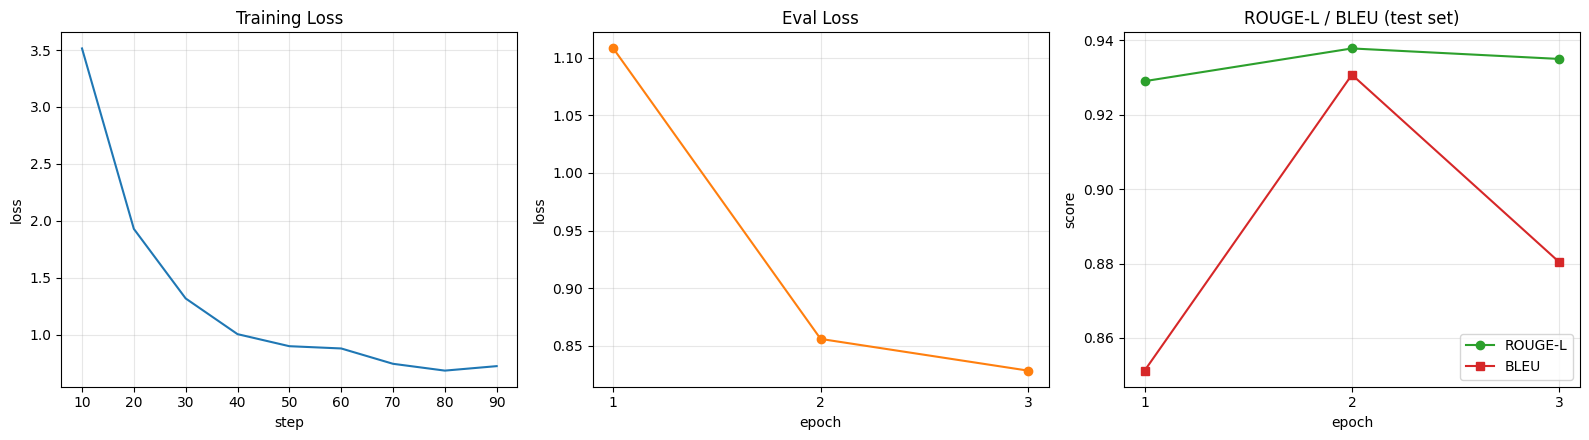

In [10]:
import matplotlib.pyplot as plt

# 1) 로그에서 train/eval loss 추출
logs = trainer.state.log_history
train_loss = [(l["step"], l["loss"]) for l in logs if "loss" in l]
eval_loss  = [(l["epoch"], l["eval_loss"]) for l in logs if "eval_loss" in l]

# 2) 콜백에서 epoch별 rouge/bleu 추출
hist   = gen_cb.history
epochs = [h["epoch"]  for h in hist]
rouges = [h["rougeL"] for h in hist]
bleus  = [h["bleu"]   for h in hist]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.5))

# ── 1) Training Loss (step별) ──
if train_loss:
    ax1.plot(*zip(*train_loss), color="tab:blue")
ax1.set_xlabel("step")
ax1.set_ylabel("loss")
ax1.set_title("Training Loss")
ax1.grid(alpha=0.3)

# ── 2) Eval Loss (epoch별) ──
if eval_loss:
    ax2.plot(*zip(*eval_loss), "o-", color="tab:orange")
ax2.set_xlabel("epoch")
ax2.set_ylabel("loss")
ax2.set_title("Eval Loss")
ax2.set_xticks(epochs)
ax2.grid(alpha=0.3)

# ── 3) ROUGE-L / BLEU (epoch별, test set) ──
ax3.plot(epochs, rouges, "o-", label="ROUGE-L", color="tab:green")
ax3.plot(epochs, bleus,  "s-", label="BLEU",    color="tab:red")
ax3.set_xlabel("epoch")
ax3.set_ylabel("score")
ax3.set_title("ROUGE-L / BLEU (test set)")
ax3.set_xticks(epochs)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 테스트셋 평가
학습에 쓰지 않은 50건으로 제품명을 생성해 정답과 비교합니다 (Exact Match 정확도).

In [11]:
correct = 0
for i, msgs in enumerate(test_msgs):
    title = str(msgs[1]["content"])
    gold  = str(msgs[-1]["content"]).strip()
    pred  = generate_product(msgs)
    ok = (pred == gold)
    correct += ok
    if i < 10:   # 앞 10건만 출력
        print(f"[{'O' if ok else 'X'}] 입력: {title}")
        print(f"     정답: {gold}")
        print(f"     예측: {pred}")
        print("-" * 60)

acc = correct / len(test_msgs)
print(f"\n테스트셋 정확도 (Exact Match): {correct}/{len(test_msgs)} = {acc:.1%}")

[O] 입력: 커세어 뱅가드 PRO 96 핫스왑 8K MGX 래피드트리거 게이밍 기계식키보드 블랙, MGX 하이퍼드라이브
     정답: 커세어 뱅가드 PRO 96
     예측: 커세어 뱅가드 PRO 96
------------------------------------------------------------
[O] 입력: 앱코 AF108PRO ABKO x SOAI 콜라보 3모드 기계식 키보드 코랄 블루, 세이야축
     정답: 앱코 AF108PRO
     예측: 앱코 AF108PRO
------------------------------------------------------------
[O] 입력: COX CK87 게이트론 LED 게이밍 기계식 크림블루, 갈축
     정답: COX CK87
     예측: COX CK87
------------------------------------------------------------
[X] 입력: 키네틱스 헤르츠87(Hertz87) CNC풀알루미늄 RGB VIA 유무선 키보드
     정답: 키네틱스 헤르츠87(Hertz87)
     예측: 키네틱스 헤르츠87
------------------------------------------------------------
[X] 입력: TFG Magnetox 2XL 듀얼8K 래피드트리거 자석축 게이밍 키보드 픽셀, POLARIS2, 35g
     정답: 한성컴퓨터 TFG Magnetox 2XL
     예측: TFG Magnetox 2XL
------------------------------------------------------------
[O] 입력: [신규출시] PMO WAVE75 유무선 CNC알루미늄 RGB VIA 기계식키보드 블랙, HMX 레서판다축
     정답: PMO WAVE75
     예측: PMO WAVE75
------------------------------------------------------------
[O]